In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/saber11_2025-1.csv')
df.shape

(1313, 85)

In [4]:
cols = [
    "punt_global",                                          # objetivo (lo que queremos explicar)
    "estu_genero", "fami_estratovivienda", "fami_tieneinternet",
    "fami_educacionmadre", "fami_educacionpadre",           # explicativas (lo que crees que influye)
    "estu_consecutivo", "cole_codigo_icfes", "cole_nombre_establecimiento",
    "cole_mcpio_ubicacion", "cole_calendario", "cole_jornada",
    "cole_naturaleza", "cole_area_ubicacion",               # contexto (para identificar/agrupar)
]

df = df[cols]
df.shape

(1313, 14)

In [5]:
df.head()

,punt_global,estu_genero,fami_estratovivienda,fami_tieneinternet,fami_educacionmadre,fami_educacionpadre,estu_consecutivo,cole_codigo_icfes,cole_nombre_establecimiento,cole_mcpio_ubicacion,cole_calendario,cole_jornada,cole_naturaleza,cole_area_ubicacion
0,335,F,Estrato 5,Si,Postgrado,Educación profesional completa,SB11202510069266,182,COLEGIO CRISTOBAL COLON THE COLUMBUS SCHOOL,ENVIGADO,B,COMPLETA,NO OFICIAL,RURAL
1,302,M,Estrato 5,Si,Postgrado,Postgrado,SB11202510003099,126409,CORPORACION COLEGIO CUMBRES,ENVIGADO,B,COMPLETA,NO OFICIAL,URBANA
2,225,M,NaN,NaN,NaN,NaN,SB11202510054057,66506,INSTITUCION EDUCATIVA FONTIDUEÑO JAIME ARANGO ...,BELLO,A,MAÑANA,OFICIAL,URBANO
3,197,M,Estrato 2,Si,Secundaria (Bachillerato) completa,Primaria incompleta,SB11202510053170,729624,INSTITUCIÓN EDUCATIVA ALIANZA PARA LA EDUCACIÓ...,ITAGÜÍ,A,MAÑANA,NO OFICIAL,RURAL
4,218,M,NaN,NaN,NaN,NaN,SB11202510053800,66506,INSTITUCION EDUCATIVA FONTIDUEÑO JAIME ARANGO ...,BELLO,A,MAÑANA,OFICIAL,URBANO


In [7]:
df.info()

#Visualización de de columnas con datos faltantes
#Registros totales 1313
#fami_estratovivienda 1120
#fami_tieneinternet 1122
#fami_educacionmadre 1120
#fami_educacionpadre 1122

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   punt_global                  1313 non-null   int64
 1   estu_genero                  1313 non-null   str  
 2   fami_estratovivienda         1120 non-null   str  
 3   fami_tieneinternet           1122 non-null   str  
 4   fami_educacionmadre          1120 non-null   str  
 5   fami_educacionpadre          1122 non-null   str  
 6   estu_consecutivo             1313 non-null   str  
 7   cole_codigo_icfes            1313 non-null   int64
 8   cole_nombre_establecimiento  1313 non-null   str  
 9   cole_mcpio_ubicacion         1313 non-null   str  
 10  cole_calendario              1313 non-null   str  
 11  cole_jornada                 1313 non-null   str  
 12  cole_naturaleza              1313 non-null   str  
 13  cole_area_ubicacion          1313 non-null   str  
dtypes: 

In [8]:
(df.isnull().mean() * 100).round(1)

# % de datos faltantes por columna

punt_global                     0.0
estu_genero                     0.0
fami_estratovivienda           14.7
fami_tieneinternet             14.5
fami_educacionmadre            14.7
fami_educacionpadre            14.5
estu_consecutivo                0.0
cole_codigo_icfes               0.0
cole_nombre_establecimiento     0.0
cole_mcpio_ubicacion            0.0
cole_calendario                 0.0
cole_jornada                    0.0
cole_naturaleza                 0.0
cole_area_ubicacion             0.0
dtype: float64

In [9]:
print("Filas duplicadas:", df.duplicated().sum())
print("IDs repetidos:", df.duplicated(subset="estu_consecutivo").sum())

#registros duplicados

Filas duplicadas: 0
IDs repetidos: 0


In [10]:
#categorias por variables
#visualización de repetición de valores,
#verificar mal escritas

for c in ["estu_genero", "fami_estratovivienda", "fami_tieneinternet",
          "fami_educacionmadre", "fami_educacionpadre", "cole_area_ubicacion"]:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- estu_genero ---
estu_genero
M    669
F    644
Name: count, dtype: int64

--- fami_estratovivienda ---
fami_estratovivienda
Estrato 6      355
Estrato 5      201
NaN            193
Estrato 3      156
Estrato 2      147
Estrato 4      123
Estrato 1      108
Sin Estrato     30
Name: count, dtype: int64

--- fami_tieneinternet ---
fami_tieneinternet
Si     1024
NaN     191
No       98
Name: count, dtype: int64

--- fami_educacionmadre ---
fami_educacionmadre
Educación profesional completa          375
Postgrado                               239
NaN                                     193
Secundaria (Bachillerato) completa      135
Primaria incompleta                      74
Secundaria (Bachillerato) incompleta     65
Técnica o tecnológica completa           63
Primaria completa                        48
No sabe                                  35
Técnica o tecnológica incompleta         30
Educación profesional incompleta         28
Ninguno                                  26
No Aplica

In [11]:
#Como parte del tratamiento de datos
#La columna ubicacion aparece "urbano" y "urbana", se unifican a "urbana"
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].replace({"URBANO": "URBANA"})
df["cole_area_ubicacion"].value_counts()

cole_area_ubicacion
URBANA    863
RURAL     450
Name: count, dtype: int64

In [12]:
#Descripción de variable objetivo
#cuantos count
#promedio mean, mínimo min, máximo max

df["punt_global"].describe()

count    1313.000000
mean      277.599391
std        70.661893
min        93.000000
25%       215.000000
50%       286.000000
75%       339.000000
max       427.000000
Name: punt_global, dtype: float64

Matplotlib is building the font cache; this may take a moment.


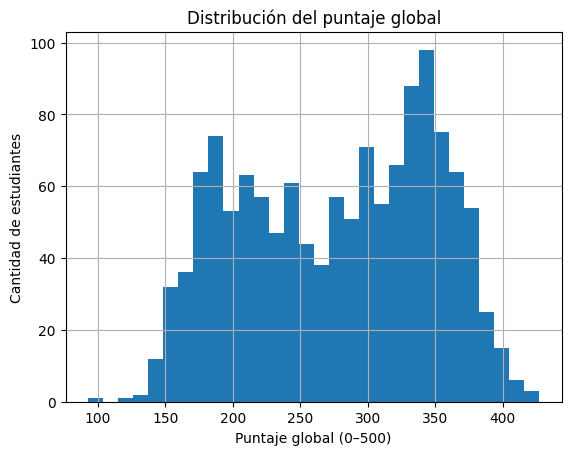

In [13]:
# visualización de variable objetivo de manera gráfica

import matplotlib.pyplot as plt

df["punt_global"].hist(bins=30)
plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global (0–500)")
plt.ylabel("Cantidad de estudiantes")
plt.show()

In [17]:
# Análisis con clasificación del puntaje global en tres niveles: Bajo, Medio y Alto.
# Cortes definidos para este análisis con base en los rangos de referencia del
# puntaje global del ICFES (≈250 = promedio nacional; >350 = puntajes altos).

df["desempeno_global"] = pd.cut(
    df["punt_global"],
    bins=[-1, 250, 350, 500],
    labels=["Bajo", "Medio", "Alto"]
)

df["desempeno_global"].value_counts()

desempeno_global
Medio    565
Bajo     515
Alto     233
Name: count, dtype: int64

In [19]:
# verificación de la nueva variable.
(df["desempeno_global"].value_counts(normalize=True) * 100).round(1)

desempeno_global
Medio    43.0
Bajo     39.2
Alto     17.7
Name: proportion, dtype: float64

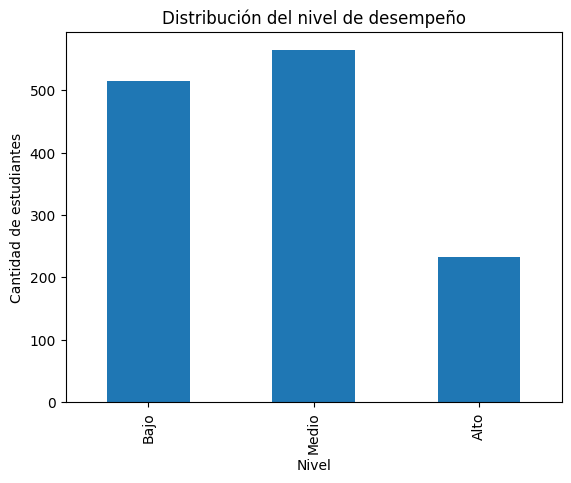

In [20]:
#visualización grafica del comportamiento
#puntaje con la clasificación bajo, medio y alto.

df["desempeno_global"].value_counts().loc[["Bajo", "Medio", "Alto"]].plot(kind="bar")
plt.title("Distribución del nivel de desempeño")
plt.xlabel("Nivel")
plt.ylabel("Cantidad de estudiantes")
plt.show()

In [22]:
#existen datos nulos o vacios en estrato familiar,
#tiene intenet, educacion madre y padre
#estos registros se pueden eliminar o imputar,
#la imputación se puede hacer con la moda, promedio 
#sin embargo, ya que son datos reales y no son númericos que se puedan predecir
#se opta por eliminar los registros con datos faltantes en estas variables
#reducir el dataset
#Esta eliminación podría inducir a un pequeño sesgo.
#se toma esta decisión para no inducir el dataset en valores que no son reales.

explicativas = ["estu_genero", "fami_estratovivienda", "fami_tieneinternet",
                "fami_educacionmadre", "fami_educacionpadre"]

df_limpio = df.dropna(subset=explicativas)

print("Antes:", df.shape)
print("Después:", df_limpio.shape)

Antes: (1313, 15)
Después: (1109, 15)


In [23]:
import matplotlib.pyplot as plt

¿Es posible clasificar el nivel de desempeño global ( bajo, medio o alto) de un estudiante del grado 11 de colegios del departamento de Antioquia mediante las pruebas Saber11 a partir del acceso a internet, nivel educativo de los padres, estrato socioeconómico y su género, con el fin de que la secretaria de educación departamental tome acciones de focalización de colegios para realizar refuerzos a estos grupos con mayor riesgo de bajo desempeño?

desempeno_global      Bajo  Medio  Alto
fami_estratovivienda                   
Estrato 1             85.7   13.3   1.0
Estrato 2             74.3   25.7   0.0
Estrato 3             58.3   32.1   9.6
Estrato 4             26.7   52.5  20.8
Estrato 5              7.5   59.2  33.3
Estrato 6              5.9   62.1  31.9
Sin Estrato           82.8   17.2   0.0


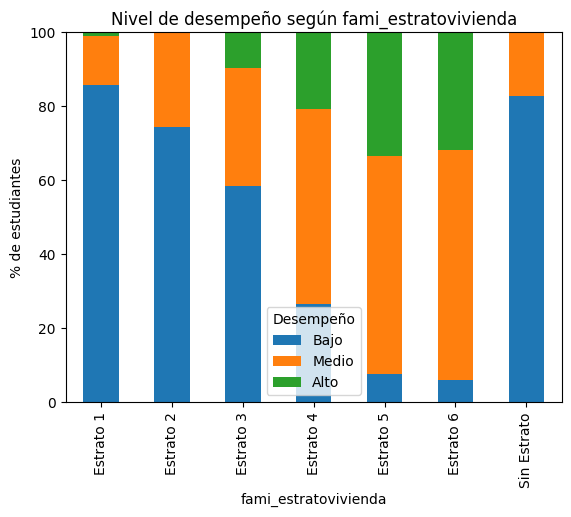

In [24]:
#verificación si estrato se relacionan con el desempeño global.

variable = "fami_estratovivienda"

#porcentaje de cada estrato está en bajo, medio y alto.
tabla = pd.crosstab(df_limpio[variable], df_limpio["desempeno_global"], normalize="index") * 100
print(tabla.round(1))

tabla[["Bajo", "Medio", "Alto"]].plot(kind="bar", stacked=True)
plt.title(f"Nivel de desempeño según {variable}")
plt.ylabel("% de estudiantes")
plt.xlabel(variable)
plt.legend(title="Desempeño")
plt.show()

desempeno_global    Bajo  Medio  Alto
fami_tieneinternet                   
No                  92.6    6.4   1.1
Si                  28.9   49.5  21.7


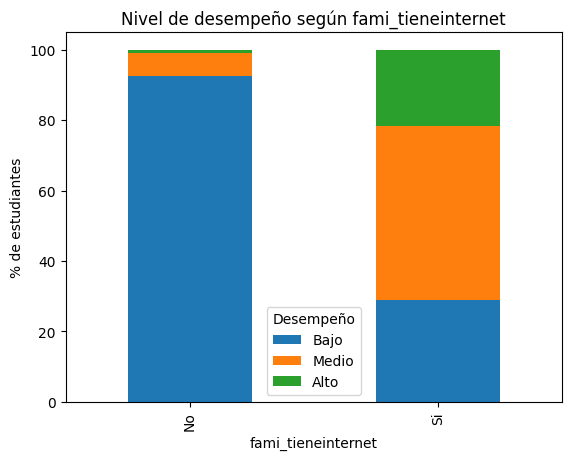

In [25]:
#verificación si tienet internet se relacionan con el desempeño global.
#

variable = "fami_tieneinternet"

#porcentaje de cada estrato está en bajo, medio y alto.
tabla = pd.crosstab(df_limpio[variable], df_limpio["desempeno_global"], normalize="index") * 100
print(tabla.round(1))

tabla[["Bajo", "Medio", "Alto"]].plot(kind="bar", stacked=True)
plt.title(f"Nivel de desempeño según {variable}")
plt.ylabel("% de estudiantes")
plt.xlabel(variable)
plt.legend(title="Desempeño")
plt.show()

desempeno_global                       Bajo  Medio  Alto
fami_educacionmadre                                     
Educación profesional completa         11.5   63.3  25.2
Educación profesional incompleta       25.0   60.7  14.3
Ninguno                                87.5    8.3   4.2
No Aplica                             100.0    0.0   0.0
No sabe                                35.3   52.9  11.8
Postgrado                               2.5   52.7  44.8
Primaria completa                      78.7   21.3   0.0
Primaria incompleta                    91.8    8.2   0.0
Secundaria (Bachillerato) completa     66.9   30.8   2.3
Secundaria (Bachillerato) incompleta   79.7   20.3   0.0
Técnica o tecnológica completa         46.0   41.3  12.7
Técnica o tecnológica incompleta       55.2   44.8   0.0


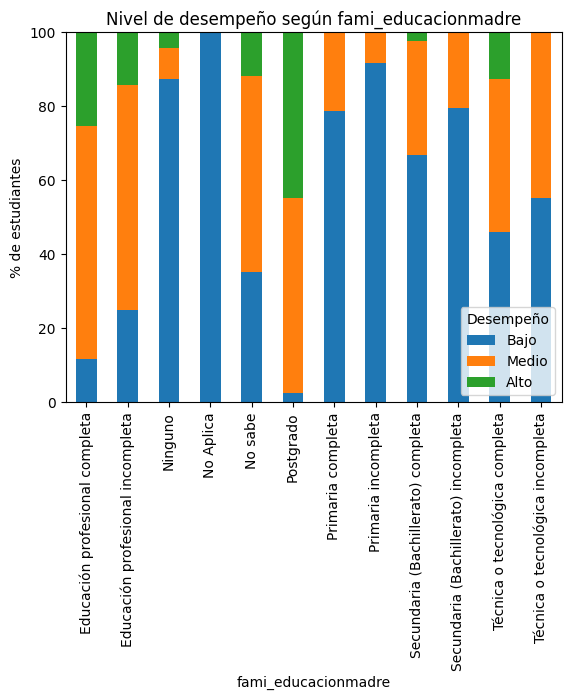

In [26]:
#verificación si educacion madre se relacionan con el desempeño global.
#

variable = "fami_educacionmadre"

#porcentaje de cada estrato está en bajo, medio y alto.
tabla = pd.crosstab(df_limpio[variable], df_limpio["desempeno_global"], normalize="index") * 100
print(tabla.round(1))

tabla[["Bajo", "Medio", "Alto"]].plot(kind="bar", stacked=True)
plt.title(f"Nivel de desempeño según {variable}")
plt.ylabel("% de estudiantes")
plt.xlabel(variable)
plt.legend(title="Desempeño")
plt.show()

desempeno_global                      Bajo  Medio  Alto
fami_educacionpadre                                    
Educación profesional completa        12.3   63.0  24.7
Educación profesional incompleta      19.2   65.4  15.4
Ninguno                               91.9    5.4   2.7
No Aplica                             70.6   17.6  11.8
No sabe                               44.9   44.9  10.1
Postgrado                              3.5   52.5  44.0
Primaria completa                     70.4   29.6   0.0
Primaria incompleta                   84.3   15.7   0.0
Secundaria (Bachillerato) completa    54.9   38.7   6.3
Secundaria (Bachillerato) incompleta  64.0   30.2   5.8
Técnica o tecnológica completa        46.9   42.9  10.2
Técnica o tecnológica incompleta      50.0   50.0   0.0


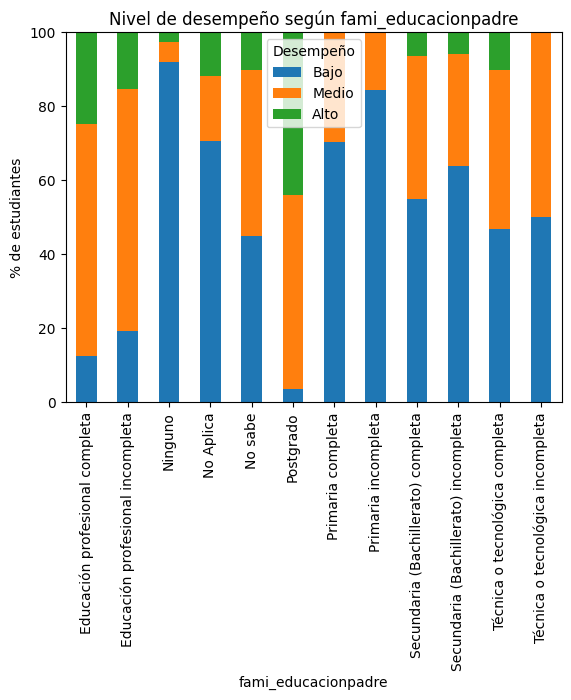

In [27]:
#verificación si eduación del padre se relacionan con el desempeño global.
#

variable = "fami_educacionpadre"

#porcentaje de cada estrato está en bajo, medio y alto.
tabla = pd.crosstab(df_limpio[variable], df_limpio["desempeno_global"], normalize="index") * 100
print(tabla.round(1))

tabla[["Bajo", "Medio", "Alto"]].plot(kind="bar", stacked=True)
plt.title(f"Nivel de desempeño según {variable}")
plt.ylabel("% de estudiantes")
plt.xlabel(variable)
plt.legend(title="Desempeño")
plt.show()

desempeno_global  Bajo  Medio  Alto
estu_genero                        
F                 38.6   43.4  17.9
M                 30.0   48.1  21.8


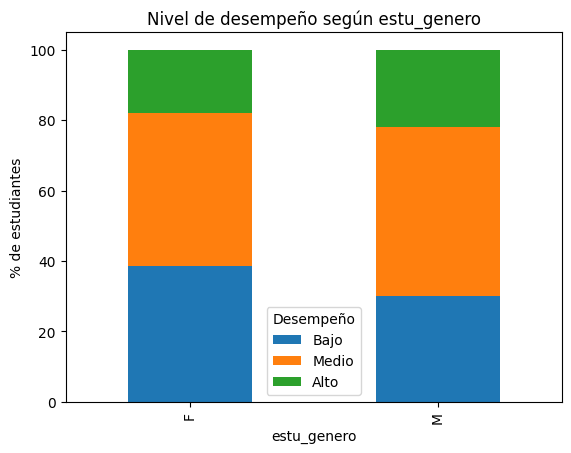

In [28]:
#verificación si genero se relacionan con el desempeño global.
#

variable = "estu_genero"

#porcentaje de cada estrato está en bajo, medio y alto.
tabla = pd.crosstab(df_limpio[variable], df_limpio["desempeno_global"], normalize="index") * 100
print(tabla.round(1))

tabla[["Bajo", "Medio", "Alto"]].plot(kind="bar", stacked=True)
plt.title(f"Nivel de desempeño según {variable}")
plt.ylabel("% de estudiantes")
plt.xlabel(variable)
plt.legend(title="Desempeño")
plt.show()